In [2]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

from scipy.cluster.hierarchy import dendrogram, linkage

import joblib
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All libraries imported successfully')

All libraries imported successfully


In [3]:
df = pd.read_csv('../data/dataCleaned.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nPrice stats:")
print(df['price'].describe())
df.head()

Shape: (96125, 9)

Columns: ['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'mpg', 'engineSize', 'brand']

Price stats:
count    96125.000000
mean     16567.395984
std       9472.798476
min       1000.000000
25%       9998.000000
50%      14200.000000
75%      20490.000000
max      99950.000000
Name: price, dtype: float64


,model,year,price,transmission,mileage,fuelType,mpg,engineSize,brand
0,A1,2017,12500,Manual,15735,Petrol,55.4,1.4,Audi
1,A6,2016,16500,Automatic,36203,Diesel,64.2,2.0,Audi
2,A1,2016,11000,Manual,29946,Petrol,55.4,1.4,Audi
3,A4,2017,16800,Automatic,25952,Diesel,67.3,2.0,Audi
4,A3,2019,17300,Manual,1998,Petrol,49.6,1.0,Audi


In [5]:
print('=' * 60)
print('Dataset Overview')
print('=' * 60)

print(f'\n Dataset Dimensions: {df.shape[0]} rows x {df.shape[1]} columns \n')

print('Data Types:')
print(df.dtypes)

print('\n Missing Values by Column:')
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else 'No missing values found.')

print('\n Descriptive Statistics:')
df.describe()

Dataset Overview

 Dataset Dimensions: 96125 rows x 9 columns 

Data Types:
model               str
year              int64
price             int64
transmission        str
mileage           int64
fuelType            str
mpg             float64
engineSize      float64
brand               str
dtype: object

 Missing Values by Column:
No missing values found.

 Descriptive Statistics:


,year,price,mileage,mpg,engineSize
count,96125.000000,96125.000000,96125.000000,96125.000000,96125.000000
mean,2017.035932,16567.395984,23618.443901,55.115521,1.665363
std,2.084389,9472.798476,20963.278605,13.434603,0.544939
min,1998.000000,1000.000000,100.000000,0.300000,1.000000
25%,2016.000000,9998.000000,8116.000000,47.100000,1.200000
50%,2017.000000,14200.000000,18066.000000,54.300000,1.600000
75%,2019.000000,20490.000000,32859.000000,62.800000,2.000000
max,2020.000000,99950.000000,241565.000000,470.800000,6.000000


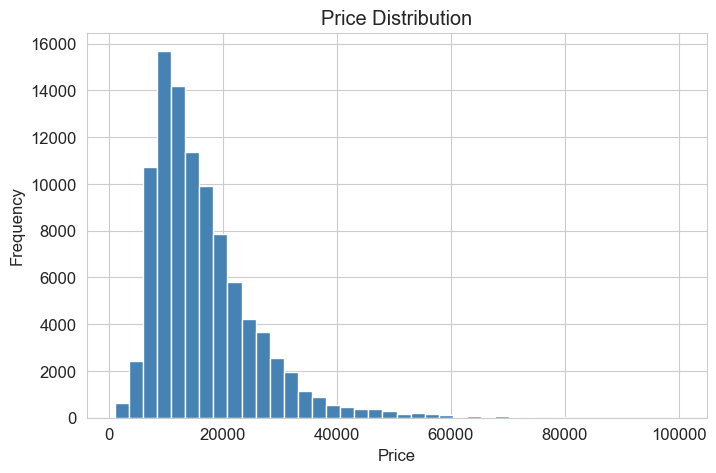

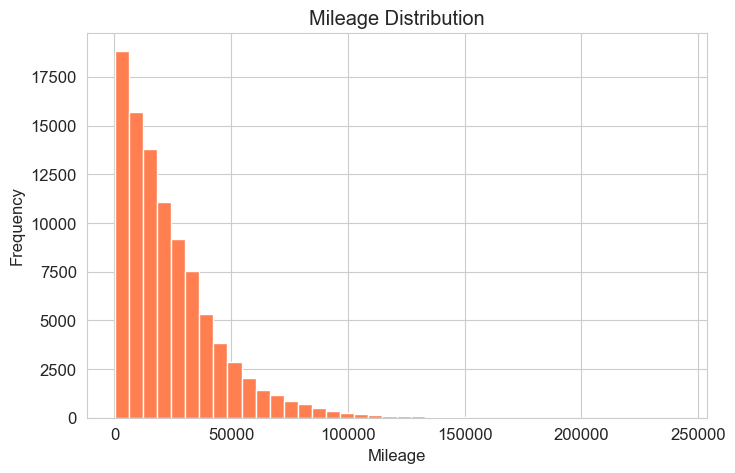

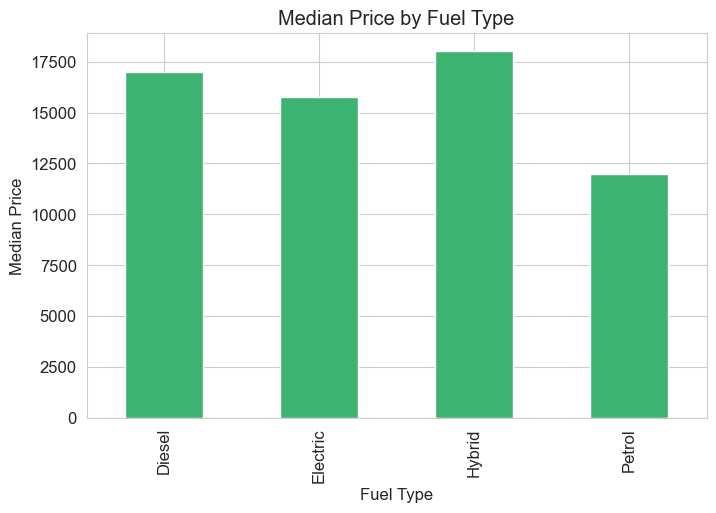

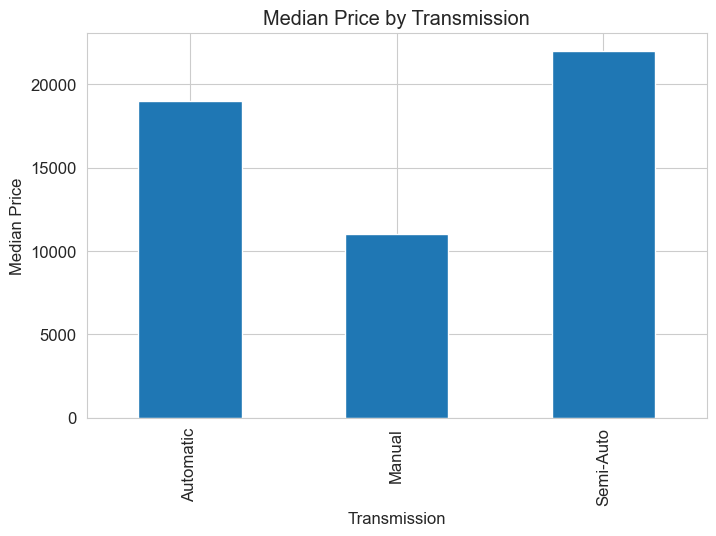

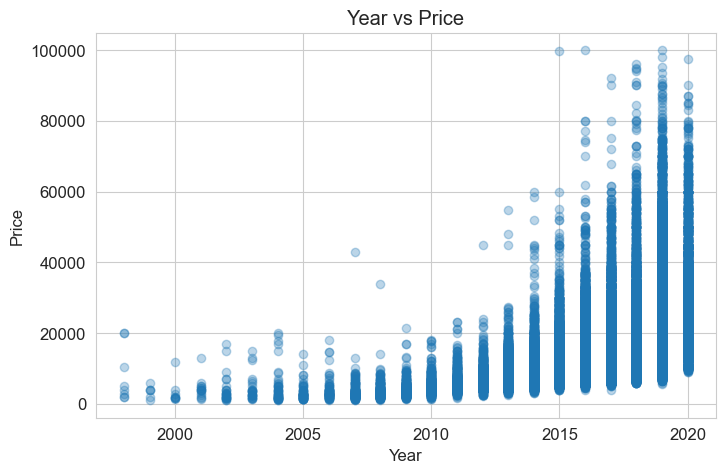

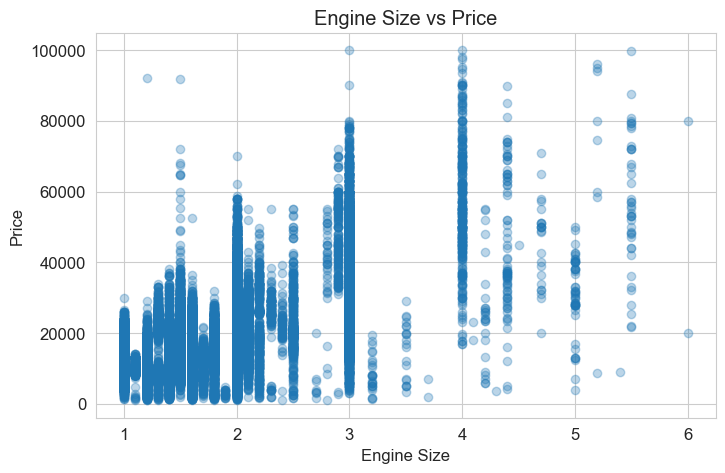

In [11]:
plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=40, color='steelblue', edgecolor='white')
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df['mileage'], bins=40, color='coral', edgecolor='white')
plt.title('Mileage Distribution')
plt.xlabel('Mileage')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8,5))

df.groupby('fuelType')['price'].median().plot(
    kind='bar',
    color='mediumseagreen'
)

plt.title('Median Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Median Price')
plt.show()

plt.figure(figsize=(8,5))

df.groupby('transmission')['price'].median().plot(
    kind='bar'
)

plt.title('Median Price by Transmission')
plt.xlabel('Transmission')
plt.ylabel('Median Price')
plt.show()

plt.figure(figsize=(8,5))

plt.scatter(
    df['year'],
    df['price'],
    alpha=0.3
)

plt.title('Year vs Price')
plt.xlabel('Year')
plt.ylabel('Price')
plt.show()

plt.figure(figsize=(8,5))

plt.scatter(
    df['engineSize'],
    df['price'],
    alpha=0.3
)

plt.title('Engine Size vs Price')
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.show()

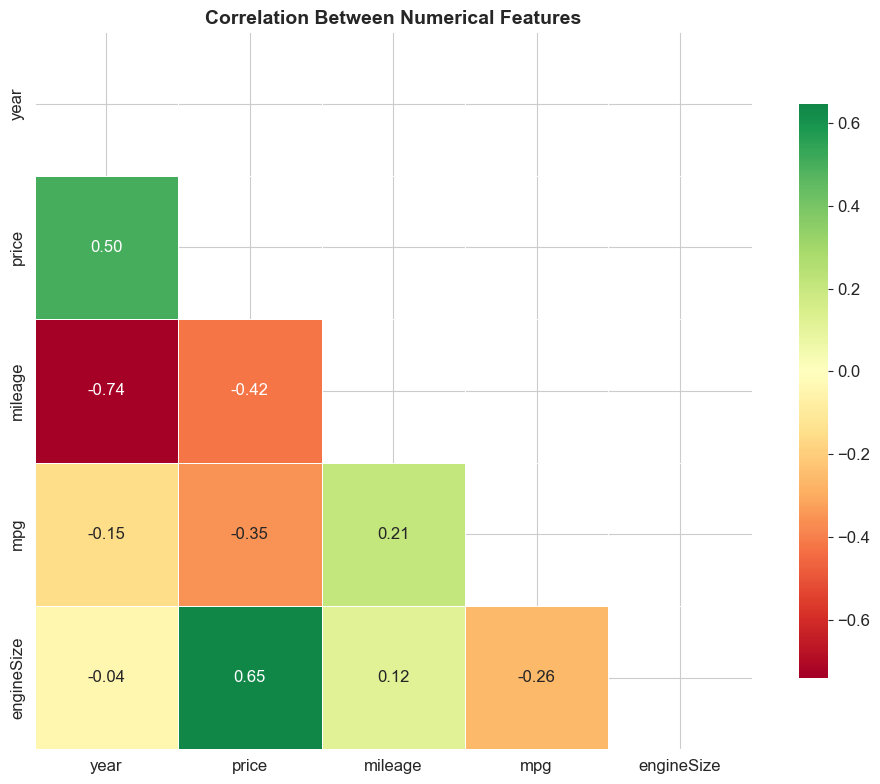

Graph saved: plots/correlation_heatmap.png


In [13]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(10, 8))

corr_matrix = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlation Between Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig(
    'plots/correlation_heatmap.png', 
    dpi=150, 
    bbox_inches='tight'
)

plt.show()
print('Graph saved: plots/correlation_heatmap.png')

In [14]:
print('=' * 60)
print('FEATURE SELECTION FOR CLUSTERING')
print('=' * 60)

feature_justification = {
    'year': 'Production year - newer vehicles tend to have higher market value',
    'mileage': 'Mileage - indicates vehicle usage and wear',
    'engineSize': 'Engine size - related to performance and vehicle category',
    'mpg': 'Fuel efficiency - reflects operating costs',
    'price': 'Market value - helps identify natural market segments'
}

print('\nSelected Features and Justification:')

for feat, reason in feature_justification.items():
    print(f'  {feat:12s} -> {reason}')

print('\nExcluded Features:')

print('  model -> High-cardinality categorical feature')
print('  brand -> Categorical feature, excluded from initial clustering')
print('  transmission -> Will be considered separately if encoded')
print('  fuelType -> Will be considered separately if encoded')

NUMERICAL_FEATURES = [
    'year',
    'mileage',
    'engineSize',
    'mpg',
    'price'
]

print(f'\nNumber of numerical features: {len(NUMERICAL_FEATURES)}')
print(NUMERICAL_FEATURES)

FEATURE SELECTION FOR CLUSTERING

Selected Features and Justification:
  year         -> Production year - newer vehicles tend to have higher market value
  mileage      -> Mileage - indicates vehicle usage and wear
  engineSize   -> Engine size - related to performance and vehicle category
  mpg          -> Fuel efficiency - reflects operating costs
  price        -> Market value - helps identify natural market segments

Excluded Features:
  model -> High-cardinality categorical feature
  brand -> Categorical feature, excluded from initial clustering
  transmission -> Will be considered separately if encoded
  fuelType -> Will be considered separately if encoded

Number of numerical features: 5
['year', 'mileage', 'engineSize', 'mpg', 'price']


In [17]:
df = df.copy()

print('Handling missing values')
initial_shape = df.shape

df = df.copy()

df['car_age'] = 2020 - df['year']

NUMERICAL_FEATURES = ['car_age','mileage','mpg','engineSize']
CATEGORICAL_FEATURES = ['transmission', 'fuelType', 'brand']
TARGET = 'price'

for col in NUMERICAL_FEATURES:
    n_null = df[col].isnull().sum()
    if n_null > 0:
        df[col] = df[col].fillna(df[col].median())
        print(f'{col}: {n_null} null values filled with median')

for col in CATEGORICAL_FEATURES:
    n_null = df[col].isnull().sum()
    if n_null > 0:
        df[col] = df[col].fillna(df[col].mode()[0])
        print(f'{col}: {n_null} null values filled with mode')

df.dropna(subset=NUMERICAL_FEATURES + CATEGORICAL_FEATURES + [TARGET], inplace=True)

print(f'Dataset after cleaning: {initial_shape} -> {df.shape}')

print('\n Encoding categorical with One-Hot Encoding')

df_encoded = pd.get_dummies(
    df,
    columns=CATEGORICAL_FEATURES,
    drop_first=True
)

encoded_cat = [
    col for col in df_encoded.columns
    if col.startswith('transmission_') 
    or col.startswith('fuelType_') 
    or col.startswith('brand_')
]

ALL_FEATURES = NUMERICAL_FEATURES + encoded_cat

X = df_encoded[ALL_FEATURES].copy()

y_true = df_encoded[TARGET].copy()

print(f'\nX features shape: {X.shape}')
print(f'y_true shape: {y_true.shape}')
print(f'Numerical features: {NUMERICAL_FEATURES}')
print(f'Encoded categorical features: {len(encoded_cat)}')

X.head()

Handling missing values
Dataset after cleaning: (96125, 12) -> (96125, 13)

 Encoding categorical with One-Hot Encoding

X features shape: (96125, 20)
y_true shape: (96125,)
Numerical features: ['car_age', 'mileage', 'mpg', 'engineSize']
Encoded categorical features: 16


,car_age,mileage,mpg,engineSize,transmission_encoded,fuelType_encoded,brand_encoded,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Petrol,brand_Bmw,brand_Ford,brand_Hyundai,brand_Mercedes,brand_Skoda,brand_Toyota,brand_Vauxhall,brand_Volkswagen
0,3,15735,55.4,1.4,1,3,0,True,False,False,False,True,False,False,False,False,False,False,False,False
1,4,36203,64.2,2.0,0,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False
2,4,29946,55.4,1.4,1,3,0,True,False,False,False,True,False,False,False,False,False,False,False,False
3,3,25952,67.3,2.0,0,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False
4,1,1998,49.6,1.0,1,3,0,True,False,False,False,True,False,False,False,False,False,False,False,False


In [19]:
print('Handling outliers using IQR clipping')

X_clean = X.copy()

for col in NUMERICAL_FEATURES:
    Q1 = X_clean[col].quantile(0.05)
    Q3 = X_clean[col].quantile(0.95)
    IQR = Q3 - Q1

    lower = Q1 - 2.5 * IQR
    upper = Q3 + 2.5 * IQR

    X_clean[col] = X_clean[col].clip(lower, upper)

print('Extreme outliers were capped using 5%-95% IQR clipping.')

print('\nStandardizing data using StandardScaler')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=ALL_FEATURES,
    index=X_clean.index
)

print(f'Before standardization (car_age): mean={X_clean["car_age"].mean():.2f}, std={X_clean["car_age"].std():.2f}')
print(f'After standardization (car_age): mean={X_scaled_df["car_age"].mean():.4f}, std={X_scaled_df["car_age"].std():.4f}')

print(f'\nShape after preprocessing: {X_scaled.shape}')

price_quantiles = pd.qcut(
    y_true,
    q=4,
    labels=['Budget', 'Economy', 'Mid-Range', 'Premium']
)

y_price_category = price_quantiles.values

le_price = LabelEncoder()
y_encoded = le_price.fit_transform(y_price_category)
price_classes = le_price.classes_

print(f'\nReal price categories, used only for comparison: {list(price_classes)}')
print(pd.Series(y_price_category).value_counts())


Handling outliers using IQR clipping
Extreme outliers were capped using 5%-95% IQR clipping.

Standardizing data using StandardScaler
Before standardization (car_age): mean=2.96, std=2.08
After standardization (car_age): mean=0.0000, std=1.0000

Shape after preprocessing: (96125, 20)

Real price categories, used only for comparison: ['Budget', 'Economy', 'Mid-Range', 'Premium']
Budget       24277
Mid-Range    24041
Premium      24005
Economy      23802
Name: count, dtype: int64


Calculating Elbow Method and clustering metrics for K=2..10...
K=2:Inertia=1659704 | Silhouette=0.1656 | Calinski-Harabasz=15220.06 | Davies-Bouldin=2.3580
K=3:Inertia=1482913 | Silhouette=0.1918 | Calinski-Harabasz=14246.97 | Davies-Bouldin=2.1449
K=4:Inertia=1351828 | Silhouette=0.2010 | Calinski-Harabasz=13525.79 | Davies-Bouldin=1.7891
K=5:Inertia=1268315 | Silhouette=0.2055 | Calinski-Harabasz=12394.46 | Davies-Bouldin=1.8086
K=6:Inertia=1149388 | Silhouette=0.2440 | Calinski-Harabasz=12930.50 | Davies-Bouldin=1.6273
K=7:Inertia=1067554 | Silhouette=0.2683 | Calinski-Harabasz=12829.29 | Davies-Bouldin=1.5048
K=8:Inertia=976436 | Silhouette=0.2964 | Calinski-Harabasz=13303.89 | Davies-Bouldin=1.3997
K=9:Inertia=887081 | Silhouette=0.3031 | Calinski-Harabasz=14023.57 | Davies-Bouldin=1.2467
K=10:Inertia=821152 | Silhouette=0.3096 | Calinski-Harabasz=14323.51 | Davies-Bouldin=1.3046


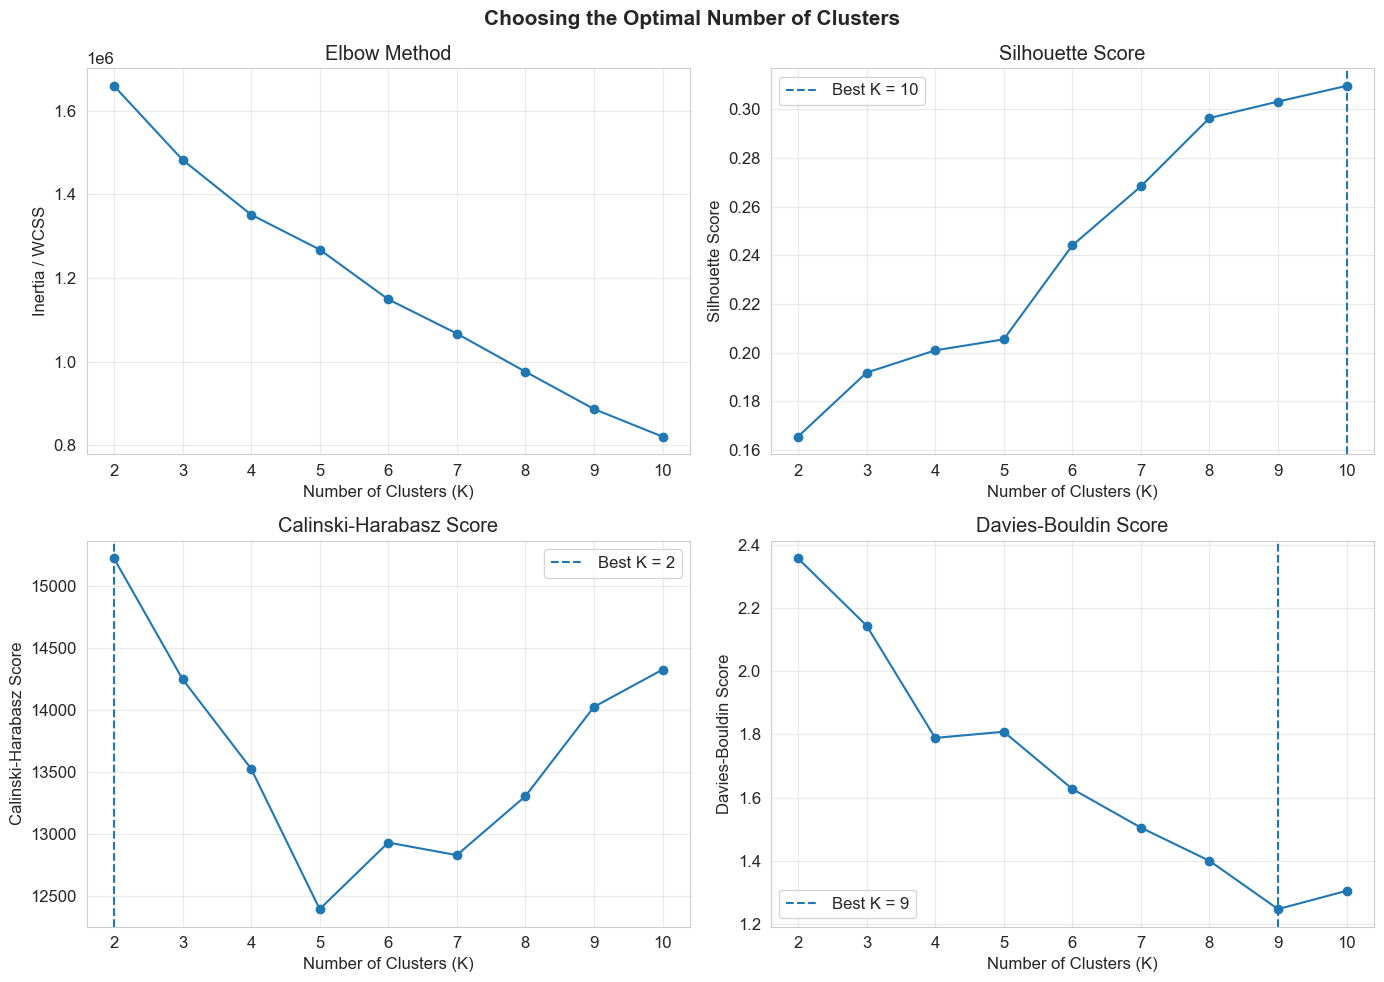


Best K according to Silhouette Score: K = 10
Best K according to Calinski-Harabasz Score: K = 2
Best K according to Davies-Bouldin Score: K = 9


In [22]:
print('Calculating Elbow Method and clustering metrics for K=2..10...')

K_range = range(2,11)

inertia_values = []
silhouette_values = []
calinski_values = []
davies_values = []

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    inertia_values.append(kmeans.inertia_)

    silhouette = silhouette_score(
        X_scaled,
        labels,
        sample_size=10000,
        random_state=RANDOM_STATE
    )

    calinski = calinski_harabasz_score(X_scaled, labels)
    davies = davies_bouldin_score(X_scaled, labels)

    silhouette_values.append(silhouette)
    calinski_values.append(calinski)
    davies_values.append(davies)

    print(
        f'K={k}:'
        f'Inertia={kmeans.inertia_:.0f} | '
        f'Silhouette={silhouette:.4f} | '
        f'Calinski-Harabasz={calinski:.2f} | '
        f'Davies-Bouldin={davies:.4f}'
    )

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Choosing the Optimal Number of Clusters', fontsize=15, fontweight='bold')


axes[0, 0].plot(K_range, inertia_values, marker='o')
axes[0, 0].set_title('Elbow Method')
axes[0, 0].set_xlabel('Number of Clusters (K)')
axes[0, 0].set_ylabel('Inertia / WCSS')
axes[0, 0].grid(True, alpha=0.4)

best_k_silhouette = list(K_range)[np.argmax(silhouette_values)]

axes[0, 1].plot(K_range, silhouette_values, marker='o')
axes[0, 1].axvline(
    x=best_k_silhouette,
    linestyle='--',
    label=f'Best K = {best_k_silhouette}'
)
axes[0, 1].set_title('Silhouette Score')
axes[0, 1].set_xlabel('Number of Clusters (K)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.4)

best_k_ch = list(K_range)[np.argmax(calinski_values)]

axes[1, 0].plot(K_range, calinski_values, marker='o')
axes[1, 0].axvline(
    x=best_k_ch,
    linestyle='--',
    label=f'Best K = {best_k_ch}'
)
axes[1, 0].set_title('Calinski-Harabasz Score')
axes[1, 0].set_xlabel('Number of Clusters (K)')
axes[1, 0].set_ylabel('Calinski-Harabasz Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.4)

best_k_db = list(K_range)[np.argmin(davies_values)]

axes[1, 1].plot(K_range, davies_values, marker='o')
axes[1, 1].axvline(
    x=best_k_db,
    linestyle='--',
    label=f'Best K = {best_k_db}'
)
axes[1, 1].set_title('Davies-Bouldin Score')
axes[1, 1].set_xlabel('Number of Clusters (K)')
axes[1, 1].set_ylabel('Davies-Bouldin Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.4)

plt.tight_layout()

plt.savefig(
    'plots/elbow_silhouette.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(f'\nBest K according to Silhouette Score: K = {best_k_silhouette}')
print(f'Best K according to Calinski-Harabasz Score: K = {best_k_ch}')
print(f'Best K according to Davies-Bouldin Score: K = {best_k_db}')

In [23]:
print('=' * 60)
print('K-MEANS EXPERIMENTS')
print('=' * 60)

kmeans_experiments = [
    (2, 'k-means++', 10, 'K=2, k-means++'),
    (4, 'k-means++', 10, 'K=4, k-means++'),
    (6, 'k-means++', 10, 'K=6, k-means++'),
    (8, 'k-means++', 10, 'K=8, k-means++'),
    (9, 'k-means++', 10, 'K=9, k-means++ - Davies-Bouldin candidate'),
    (9, 'random', 10, 'K=9, random init'),
    (9, 'k-means++', 1, 'K=9, n_init=1'),
    (10, 'k-means++', 10, 'K=10, k-means++ - Silhouette candidate'),
    (10, 'random', 10, 'K=10, random init')
]

km_results = []

print(f'\n{"Configuration":<45} {"Inertia":>12} {"Silhouette":>12} {"CH-Score":>12} {"DB-Score":>10}')
print('-' * 100)

for n_clusters, init, n_init, label in kmeans_experiments:
    km = KMeans(
        n_clusters=n_clusters,
        init=init,
        n_init=n_init,
        random_state=RANDOM_STATE
    )

    labels = km.fit_predict(X_scaled)

    sil = silhouette_score(
        X_scaled,
        labels,
        sample_size=10000,
        random_state=RANDOM_STATE
    )

    ch = calinski_harabasz_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)

    km_results.append({
        'Configuration': label,
        'n_clusters': n_clusters,
        'init': init,
        'n_init': n_init,
        'Inertia': round(km.inertia_, 0),
        'Silhouette': round(sil, 4),
        'CH_Score': round(ch, 1),
        'DB_Score': round(db, 4)
    })

    marker = '[OPTIMAL]' if n_clusters == 9 and init == 'k-means++' and n_init == 10 else '  '

    print(
        f'{marker} {label:<43} '
        f'{km.inertia_:>12.0f} '
        f'{sil:>12.4f} '
        f'{ch:>12.1f} '
        f'{db:>10.4f}'
    )

km_results_df = pd.DataFrame(km_results)

print('\nComplete K-Means Experiment Results:')
print(
    km_results_df[
        ['Configuration', 'Silhouette', 'CH_Score', 'DB_Score']
    ].to_string(index=False)
)

K-MEANS EXPERIMENTS

Configuration                                      Inertia   Silhouette     CH-Score   DB-Score
----------------------------------------------------------------------------------------------------
   K=2, k-means++                                   1659704       0.1656      15220.1     2.3580
   K=4, k-means++                                   1351828       0.2010      13525.8     1.7891
   K=6, k-means++                                   1149388       0.2440      12930.5     1.6273
   K=8, k-means++                                    976436       0.2964      13303.9     1.3997
[OPTIMAL] K=9, k-means++ - Davies-Bouldin candidate         887081       0.3031      14023.6     1.2467
   K=9, random init                                  951033       0.2811      12272.6     1.4784
   K=9, n_init=1                                     951024       0.2811      12272.9     1.4805
   K=10, k-means++ - Silhouette candidate            821152       0.3096      14323.5     1.3046

In [24]:
print('=' * 60)
print('DBSCAN EXPERIMENTS')
print('=' * 60)

DBSCAN_SAMPLE_SIZE = 10000

if X_scaled.shape[0] > DBSCAN_SAMPLE_SIZE:
    sample_indices = np.random.choice(
        X_scaled.shape[0],
        size=DBSCAN_SAMPLE_SIZE,
        replace=False
    )
    X_dbscan = X_scaled[sample_indices]
else:
    X_dbscan = X_scaled

print(f'DBSCAN sample size: {X_dbscan.shape[0]} rows')

dbscan_experiments = [
    (0.5, 5,  'eps=0.5, min_samples=5'),
    (0.7, 5,  'eps=0.7, min_samples=5'),
    (1.0, 5,  'eps=1.0, min_samples=5'),
    (1.2, 5,  'eps=1.2, min_samples=5'),
    (1.5, 5,  'eps=1.5, min_samples=5'),
    (1.0, 10, 'eps=1.0, min_samples=10'),
    (1.2, 10, 'eps=1.2, min_samples=10'),
]

db_results = []

print(f'\n{"Configuration":<30} {"Clusters":>10} {"Noise":>10} {"Noise %":>10} {"Silhouette":>12}')
print('-' * 80)

for eps, min_samples, label in dbscan_experiments:
    dbscan = DBSCAN(
        eps=eps,
        min_samples=min_samples,
        metric='euclidean'
    )

    labels_db = dbscan.fit_predict(X_dbscan)

    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    n_noise = np.sum(labels_db == -1)
    noise_percentage = (n_noise / len(labels_db)) * 100

    if n_clusters >= 2:
        non_noise_mask = labels_db != -1

        if non_noise_mask.sum() > n_clusters:
            silhouette = silhouette_score(
                X_dbscan[non_noise_mask],
                labels_db[non_noise_mask],
                sample_size=min(5000, non_noise_mask.sum()),
                random_state=RANDOM_STATE
            )
        else:
            silhouette = np.nan
    else:
        silhouette = np.nan

    db_results.append({
        'Configuration': label,
        'eps': eps,
        'min_samples': min_samples,
        'Clusters': n_clusters,
        'Noise': n_noise,
        'Noise_Percentage': round(noise_percentage, 2),
        'Silhouette': round(silhouette, 4) if not np.isnan(silhouette) else 'N/A'
    })

    silhouette_text = f'{silhouette:.4f}' if not np.isnan(silhouette) else 'N/A'

    print(
        f'{label:<30} '
        f'{n_clusters:>10} '
        f'{n_noise:>10} '
        f'{noise_percentage:>9.2f}% '
        f'{silhouette_text:>12}'
    )

db_results_df = pd.DataFrame(db_results)

print('\nComplete DBSCAN Experiment Results:')
print(db_results_df.to_string(index=False))

DBSCAN EXPERIMENTS
DBSCAN sample size: 10000 rows

Configuration                    Clusters      Noise    Noise %   Silhouette
--------------------------------------------------------------------------------
eps=0.5, min_samples=5                194       2193     21.93%       0.3416
eps=0.7, min_samples=5                144       1016     10.16%       0.3301
eps=1.0, min_samples=5                 87        471      4.71%       0.4473
eps=1.2, min_samples=5                 81        289      2.89%       0.4528
eps=1.5, min_samples=5                 75        191      1.91%       0.4572
eps=1.0, min_samples=10                72        751      7.51%       0.4588
eps=1.2, min_samples=10                65        495      4.95%       0.4575

Complete DBSCAN Experiment Results:
          Configuration  eps  min_samples  Clusters  Noise  Noise_Percentage  Silhouette
 eps=0.5, min_samples=5  0.5            5       194   2193             21.93      0.3416
 eps=0.7, min_samples=5  0.7         

HIERARCHICAL CLUSTERING EXPERIMENTS
Hierarchical clustering sample size: 10000 rows

Configuration                         Silhouette     CH-Score   DB-Score
---------------------------------------------------------------------------
            K=4, ward linkage                       0.1449       1309.1     1.7587
            K=6, ward linkage                       0.1931       1384.3     1.4419
            K=8, ward linkage                       0.2625       1462.6     1.2975
            K=9, ward linkage                       0.2756       1538.2     1.3338
[CANDIDATE] K=10, ward linkage                      0.2900       1595.0     1.2966
            K=10, complete linkage                  0.1160        475.7     1.5306
            K=10, average linkage                   0.1797        317.4     0.9954

Complete Hierarchical Clustering Experiment Results:
         Configuration  n_clusters  linkage    metric  Silhouette  CH_Score  DB_Score
     K=4, ward linkage           4     ward e

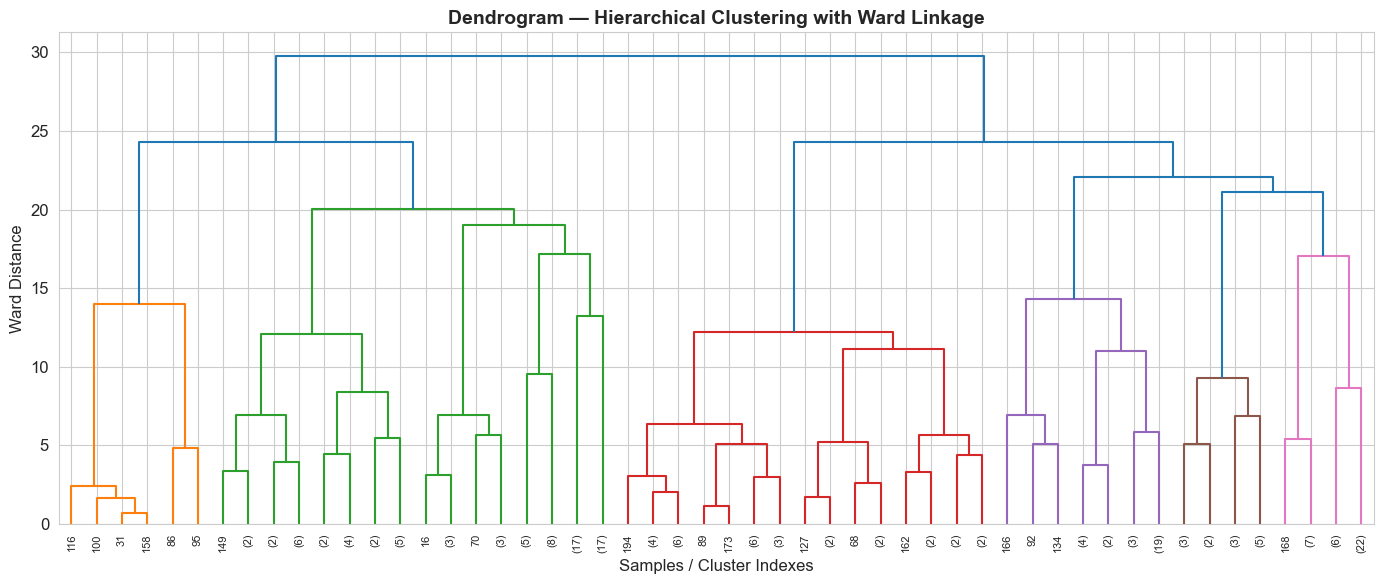

In [25]:
print('=' * 60)
print('HIERARCHICAL CLUSTERING EXPERIMENTS')
print('=' * 60)


HC_SAMPLE_SIZE = 10000

if X_scaled.shape[0] > HC_SAMPLE_SIZE:
    sample_indices = np.random.choice(
        X_scaled.shape[0],
        size=HC_SAMPLE_SIZE,
        replace=False
    )
    X_hc = X_scaled[sample_indices]
else:
    X_hc = X_scaled

print(f'Hierarchical clustering sample size: {X_hc.shape[0]} rows')

hc_experiments = [
    (4, 'ward', 'euclidean', 'K=4, ward linkage'),
    (6, 'ward', 'euclidean', 'K=6, ward linkage'),
    (8, 'ward', 'euclidean', 'K=8, ward linkage'),
    (9, 'ward', 'euclidean', 'K=9, ward linkage'),
    (10, 'ward', 'euclidean', 'K=10, ward linkage'),
    (10, 'complete', 'euclidean', 'K=10, complete linkage'),
    (10, 'average', 'euclidean', 'K=10, average linkage')
]

hc_results = []

print(f'\n{"Configuration":<35} {"Silhouette":>12} {"CH-Score":>12} {"DB-Score":>10}')
print('-' * 75)

for n_clusters, linkage_method, metric, label in hc_experiments:
    hc = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage=linkage_method,
        metric=metric
    )

    labels_hc = hc.fit_predict(X_hc)

    silhouette = silhouette_score(
        X_hc,
        labels_hc,
        sample_size=min(5000, X_hc.shape[0]),
        random_state=RANDOM_STATE
    )

    ch = calinski_harabasz_score(X_hc, labels_hc)
    db = davies_bouldin_score(X_hc, labels_hc)

    hc_results.append({
        'Configuration': label,
        'n_clusters': n_clusters,
        'linkage': linkage_method,
        'metric': metric,
        'Silhouette': round(silhouette, 4),
        'CH_Score': round(ch, 1),
        'DB_Score': round(db, 4)
    })

    marker = '[CANDIDATE]' if n_clusters == 10 and linkage_method == 'ward' else '           '

    print(
        f'{marker} {label:<33} '
        f'{silhouette:>12.4f} '
        f'{ch:>12.1f} '
        f'{db:>10.4f}'
    )

hc_results_df = pd.DataFrame(hc_results)

print('\nComplete Hierarchical Clustering Experiment Results:')
print(hc_results_df.to_string(index=False))


print('\nCreating dendrogram using a smaller sample of 200 rows...')

dendrogram_sample_size = 200

sample_indices_dendrogram = np.random.choice(
    X_scaled.shape[0],
    size=min(dendrogram_sample_size, X_scaled.shape[0]),
    replace=False
)

X_dendrogram = X_scaled[sample_indices_dendrogram]

Z = linkage(X_dendrogram, method='ward')

plt.figure(figsize=(14, 6))

plt.title(
    'Dendrogram — Hierarchical Clustering with Ward Linkage',
    fontsize=14,
    fontweight='bold'
)

dendrogram(
    Z,
    truncate_mode='level',
    p=5,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=0.7 * max(Z[:, 2])
)

plt.xlabel('Samples / Cluster Indexes')
plt.ylabel('Ward Distance')
plt.tight_layout()

plt.savefig(
    'plots/dendrogram.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

In [28]:
print('=' * 60)
print('FINAL CLUSTERING MODELS')

OPTIMAL_K = 10

kmeans_final = KMeans(
    n_clusters=OPTIMAL_K,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=RANDOM_STATE
)

labels_kmeans = kmeans_final.fit_predict(X_scaled)

kmeans_distribution = {
    int(k): int(v)
    for k, v in zip(*np.unique(labels_kmeans, return_counts=True))
}

print('\nK-Means Final Model:')
print(f'K = {OPTIMAL_K}')
print('Initialization = k-means++')
print('n_init = 10')
print(f'Inertia = {kmeans_final.inertia_:.2f}')
print(f'Cluster distribution: {kmeans_distribution}')

dbscan_final = DBSCAN(
    eps=1.0,
    min_samples=10,
    metric='euclidean'
)

labels_dbscan = dbscan_final.fit_predict(X_scaled)

n_db_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = int(np.sum(labels_dbscan == -1))
noise_percentage = (n_noise / len(labels_dbscan)) * 100

print('\nDBSCAN Final Model:')
print('eps = 1.0')
print('min_samples = 10')
print(f'Clusters found: {n_db_clusters}')
print(f'Noise points: {n_noise} ({noise_percentage:.2f}%)')

hierarchical_final = AgglomerativeClustering(
    n_clusters=OPTIMAL_K,
    linkage='ward',
    metric='euclidean'
)

labels_hierarchical = hierarchical_final.fit_predict(X_hc)

hierarchical_distribution = {
    int(k): int(v)
    for k, v in zip(*np.unique(labels_hierarchical, return_counts=True))
}

print('\nHierarchical Clustering Final Model:')
print(f'K = {OPTIMAL_K}')
print('Linkage = ward')
print(f'Sample size used: {X_hc.shape[0]}')
print(f'Cluster distribution: {hierarchical_distribution}')

FINAL CLUSTERING MODELS

K-Means Final Model:
K = 10
Initialization = k-means++
n_init = 10
Inertia = 821152.27
Cluster distribution: {0: 8376, 1: 10056, 2: 13052, 3: 14394, 4: 2959, 5: 4, 6: 11242, 7: 6076, 8: 11006, 9: 18960}

DBSCAN Final Model:
eps = 1.0
min_samples = 10
Clusters found: 117
Noise points: 1245 (1.30%)

Hierarchical Clustering Final Model:
K = 10
Linkage = ward
Sample size used: 10000
Cluster distribution: {0: 1777, 1: 1835, 2: 1283, 3: 1514, 4: 910, 5: 1298, 6: 589, 7: 1, 8: 474, 9: 319}


In [29]:
print('=' * 70)
print('CLUSTERING ALGORITHM COMPARISON')
print('=' * 70)

def evaluate_clustering(name, labels, X_data):

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int(np.sum(labels == -1))

    mask = labels != -1

    if n_clusters >= 2 and mask.sum() > n_clusters:

        sil = silhouette_score(
            X_data[mask],
            labels[mask],
            sample_size=min(10000, mask.sum()),
            random_state=RANDOM_STATE
        )

        ch = calinski_harabasz_score(
            X_data[mask],
            labels[mask]
        )

        db = davies_bouldin_score(
            X_data[mask],
            labels[mask]
        )

    else:
        sil, ch, db = 0, 0, 999

    return {
        'Algorithm': name,
        'Clusters': n_clusters,
        'Noise_Points': n_noise,
        'Silhouette': round(sil, 4),
        'Calinski_Harabasz': round(ch, 1),
        'Davies_Bouldin': round(db, 4)
    }

results = [

    evaluate_clustering(
        'K-Means (K=10)',
        labels_kmeans,
        X_scaled
    ),

    evaluate_clustering(
        'DBSCAN (eps=1.0, min_samples=10)',
        labels_dbscan,
        X_scaled
    ),

    evaluate_clustering(
        'Hierarchical (Ward, K=10)',
        labels_hierarchical,
        X_hc
    )
]

evaluation_df = pd.DataFrame(results)

print('\nComparison Table:')
print(evaluation_df.to_string(index=False))

best_idx = evaluation_df['Silhouette'].idxmax()
best_algorithm = evaluation_df.loc[best_idx, 'Algorithm']

print('\nBest Algorithm Based on Silhouette Score:')
print(best_algorithm)

print('\nHigher Silhouette values indicate better cluster separation and compactness.')

CLUSTERING ALGORITHM COMPARISON

Comparison Table:
                       Algorithm  Clusters  Noise_Points  Silhouette  Calinski_Harabasz  Davies_Bouldin
                  K-Means (K=10)        10             0      0.3096            14323.5          1.3046
DBSCAN (eps=1.0, min_samples=10)       117          1245      0.4466             6680.7          0.7850
       Hierarchical (Ward, K=10)        10             0      0.2930             1595.0          1.2966

Best Algorithm Based on Silhouette Score:
DBSCAN (eps=1.0, min_samples=10)

Higher Silhouette values indicate better cluster separation and compactness.


Creating silhouette plot


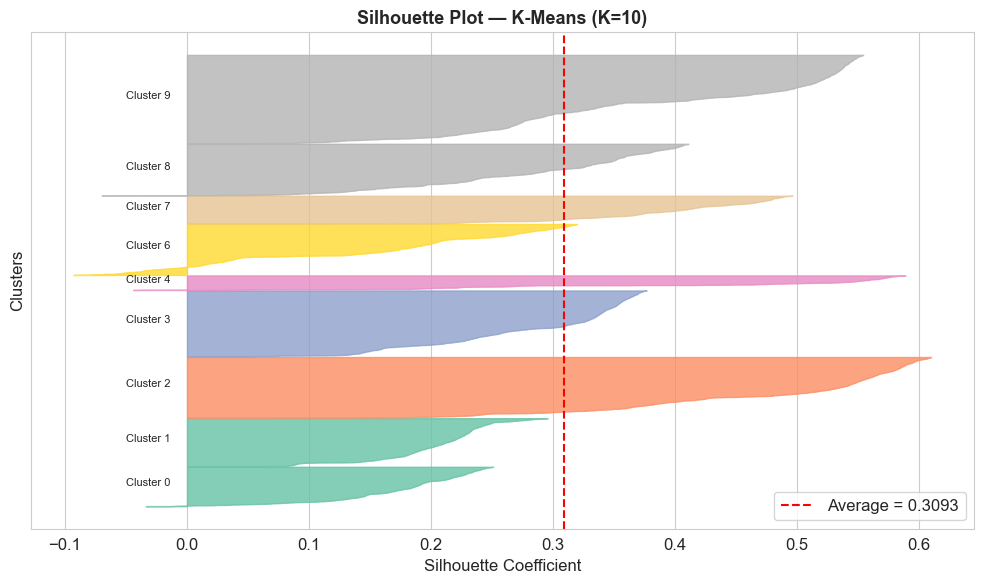

In [33]:
print('Creating silhouette plot')

SILHOUETTE_SAMPLE_SIZE = 10000

if len(X_scaled) > SILHOUETTE_SAMPLE_SIZE:
    sample_idx = np.random.choice(
        len(X_scaled),
        size=SILHOUETTE_SAMPLE_SIZE,
        replace=False
    )

    X_silhouette = X_scaled[sample_idx]
    labels_silhouette = labels_kmeans[sample_idx]

else:
    X_silhouette = X_scaled
    labels_silhouette = labels_kmeans

fig, ax = plt.subplots(figsize=(10, 6))

silhouette_vals = silhouette_samples(
    X_silhouette,
    labels_silhouette
)

avg_silhouette = silhouette_score(
    X_silhouette,
    labels_silhouette
)

y_lower = 10

colors = cm.Set2(
    np.linspace(0, 1, OPTIMAL_K)
)

for i in range(OPTIMAL_K):

    cluster_silhouette = np.sort(
        silhouette_vals[labels_silhouette == i]
    )

    size = cluster_silhouette.shape[0]

    if size < 20:
        continue

    y_upper = y_lower + size

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_silhouette,
        facecolor=colors[i],
        edgecolor=colors[i],
        alpha=0.8
    )

    ax.text(
        -0.05,
        y_lower + 0.5 * size,
        f'Cluster {i}',
        fontsize=8
    )

    y_lower = y_upper + 10

ax.axvline(
    x=avg_silhouette,
    color='red',
    linestyle='--',
    label=f'Average = {avg_silhouette:.4f}'
)

ax.set_title(
    f'Silhouette Plot — K-Means (K={OPTIMAL_K})',
    fontsize=13,
    fontweight='bold'
)

ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Clusters')
ax.legend()
ax.set_yticks([])

plt.tight_layout()

plt.savefig(
    'plots/silhouette_plot.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

Applying PCA for visualization...
Explained variance:
PCA 2D: 29.4%
PCA 3D: 39.2%
PC1: 17.08%
PC2: 12.33%


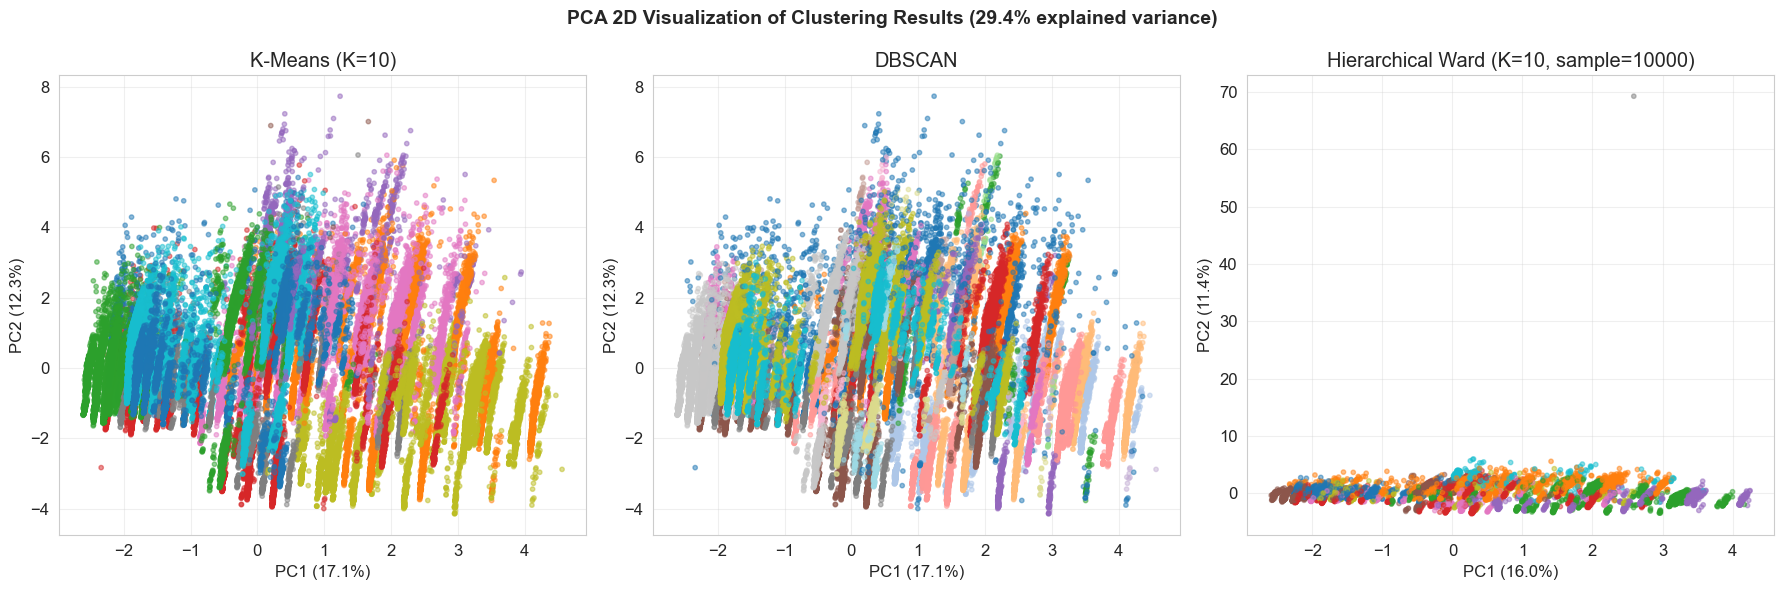

In [ ]:
print('Applying PCA for visualization')

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_3d = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca_3d = pca_3d.fit_transform(X_scaled)

var_2d = pca_2d.explained_variance_ratio_.sum() * 100
var_3d = pca_3d.explained_variance_ratio_.sum() * 100

print('Explained variance:')
print(f'PCA 2D: {var_2d:.1f}%')
print(f'PCA 3D: {var_3d:.1f}%')

for i, var in enumerate(pca_2d.explained_variance_ratio_):
    print(f'PC{i+1}: {var*100:.2f}%')

pca_hc_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_hc_pca_2d = pca_hc_2d.fit_transform(X_hc)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    f'PCA 2D Visualization of Clustering Results ({var_2d:.1f}% explained variance)',
    fontsize=14,
    fontweight='bold'
)

scatter1 = axes[0].scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=labels_kmeans,
    cmap='tab10',
    alpha=0.5,
    s=10
)

axes[0].set_title(f'K-Means (K={OPTIMAL_K})')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].grid(True, alpha=0.3)

scatter2 = axes[1].scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=labels_dbscan,
    cmap='tab20',
    alpha=0.5,
    s=10
)

axes[1].set_title('DBSCAN')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].grid(True, alpha=0.3)

scatter3 = axes[2].scatter(
    X_hc_pca_2d[:, 0],
    X_hc_pca_2d[:, 1],
    c=labels_hierarchical,
    cmap='tab10',
    alpha=0.5,
    s=10
)

axes[2].set_title(f'Hierarchical Ward (K={OPTIMAL_K}, sample={X_hc.shape[0]})')
axes[2].set_xlabel(f'PC1 ({pca_hc_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[2].set_ylabel(f'PC2 ({pca_hc_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    'plots/pca_2d_all_algorithms.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

Creating 3D PCA visualization and centroid profile


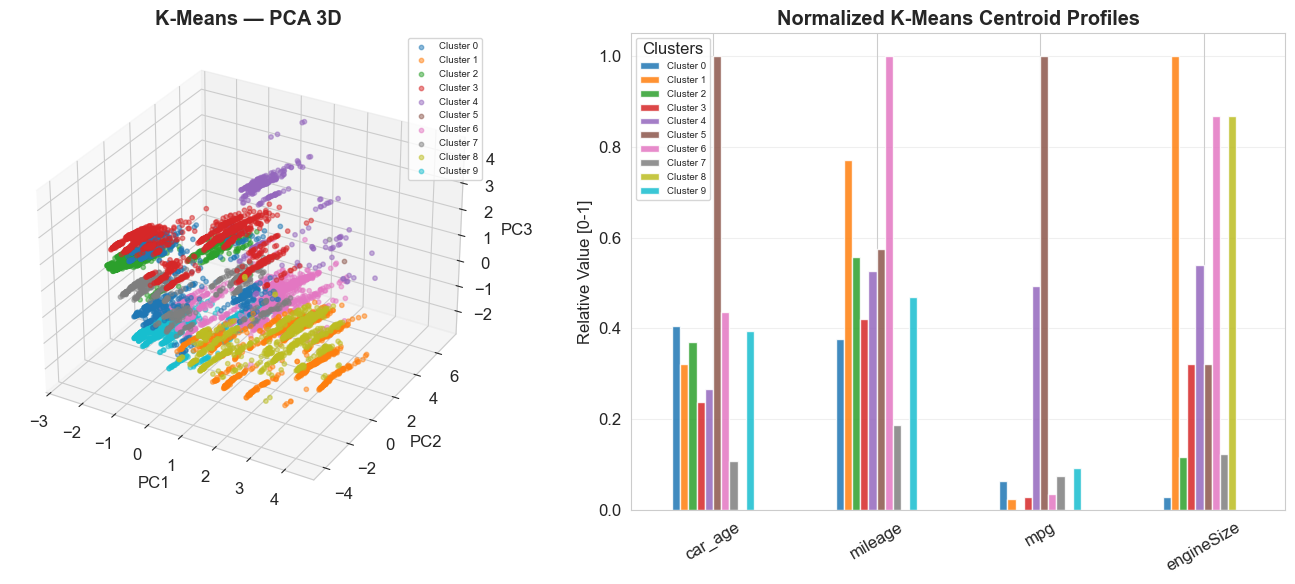


K-Means Centroids - Original Scale:
           car_age   mileage     mpg  engineSize
Cluster 0     3.20  22483.57   55.75        1.35
Cluster 1     3.02  26440.69   53.03        2.18
Cluster 2     3.12  24284.90   51.47        1.42
Cluster 3     2.83  22932.30   53.31        1.60
Cluster 4     2.90  23985.59   84.54        1.79
Cluster 5     4.50  24463.25  118.42        1.60
Cluster 6     3.27  28738.46   53.76        2.07
Cluster 7     2.54  20591.35   56.42        1.43
Cluster 8     2.31  18700.62   51.44        2.07
Cluster 9     3.17  23414.05   57.58        1.32


In [35]:
print('Creating 3D PCA visualization and centroid profile')

PLOT_SAMPLE_SIZE = 10000

if len(X_scaled) > PLOT_SAMPLE_SIZE:
    plot_indices = np.random.choice(
        len(X_scaled),
        size=PLOT_SAMPLE_SIZE,
        replace=False
    )

    X_pca_3d_plot = X_pca_3d[plot_indices]
    labels_kmeans_plot = labels_kmeans[plot_indices]

else:
    X_pca_3d_plot = X_pca_3d
    labels_kmeans_plot = labels_kmeans

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')

cmap_3d = plt.get_cmap('tab10')

for k in range(OPTIMAL_K):
    mask = labels_kmeans_plot == k

    ax1.scatter(
        X_pca_3d_plot[mask, 0],
        X_pca_3d_plot[mask, 1],
        X_pca_3d_plot[mask, 2],
        c=[cmap_3d(k / OPTIMAL_K)],
        label=f'Cluster {k}',
        s=10,
        alpha=0.5
    )

ax1.set_title('K-Means — PCA 3D', fontweight='bold')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_zlabel('PC3')
ax1.legend(fontsize=7)

ax2 = fig.add_subplot(122)

centroids_df = pd.DataFrame(
    scaler.inverse_transform(kmeans_final.cluster_centers_),
    columns=ALL_FEATURES
)

centroids_df.index = [f'Cluster {i}' for i in range(OPTIMAL_K)]

centroids_norm = centroids_df[NUMERICAL_FEATURES].copy()

for col in NUMERICAL_FEATURES:
    value_range = centroids_norm[col].max() - centroids_norm[col].min()

    if value_range > 0:
        centroids_norm[col] = (
            centroids_norm[col] - centroids_norm[col].min()
        ) / value_range

centroids_norm.T.plot(
    kind='bar',
    ax=ax2,
    colormap='tab10',
    edgecolor='white',
    alpha=0.85
)

ax2.set_title('Normalized K-Means Centroid Profiles', fontweight='bold')
ax2.set_ylabel('Relative Value [0-1]')
ax2.tick_params(axis='x', rotation=30)
ax2.legend(title='Clusters', fontsize=7)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()

plt.savefig(
    'plots/pca3d_centroids.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print('\nK-Means Centroids - Original Scale:')
print(centroids_df[NUMERICAL_FEATURES].round(2).to_string())